<a href="https://colab.research.google.com/github/mariamsedeik-dot/mariam-/blob/main/heartguard_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Libraries Setup**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

# Data Loading & Overview

In [ ]:
df = pd.read_csv("HeartDiseaseTrain-Test(1).csv")

df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


# Duplicates Removal

In [ ]:
print("Shape before drop duplicates:", df.shape)
df = df.drop_duplicates()
print("Shape after drop duplicates:", df.shape)

Shape before drop duplicates: (1025, 14)
Shape after drop duplicates: (302, 14)


# Missing Values Check

In [ ]:
print("Missing values count:")
print(df.isnull().sum())

Missing values count:
age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64


# Data Info & Target Distribution

In [ ]:
df.info()
print(df['target'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            302 non-null    int64  
 1   sex                            302 non-null    object 
 2   chest_pain_type                302 non-null    object 
 3   resting_blood_pressure         302 non-null    int64  
 4   cholestoral                    302 non-null    int64  
 5   fasting_blood_sugar            302 non-null    object 
 6   rest_ecg                       302 non-null    object 
 7   Max_heart_rate                 302 non-null    int64  
 8   exercise_induced_angina        302 non-null    object 
 9   oldpeak                        302 non-null    float64
 10  slope                          302 non-null    object 
 11  vessels_colored_by_flourosopy  302 non-null    object 
 12  thalassemia                    302 non-null    object 


# Outliers Detection

In [ ]:
Q1 = df["cholestoral"].quantile(0.25)
Q3 = df["cholestoral"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier = df[(df['cholestoral'] < lower) | (df['cholestoral'] > upper)]
print("Outliers count in cholesterol:", len(outlier))

Outliers count in cholesterol: 5


# Plot Target Distribution

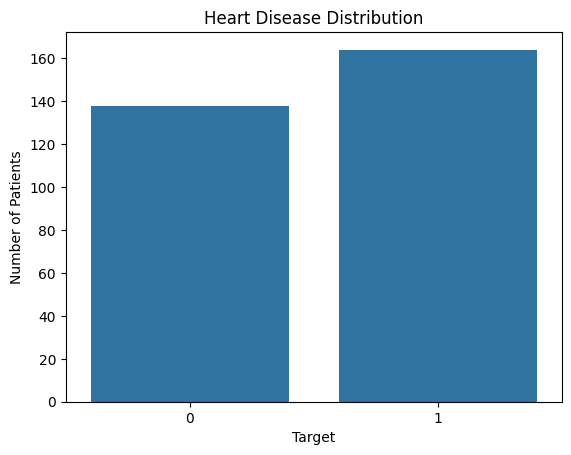

In [ ]:
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution')
plt.xlabel('Target')
plt.ylabel('Number of Patients')
plt.show()

# Plot Age Distribution

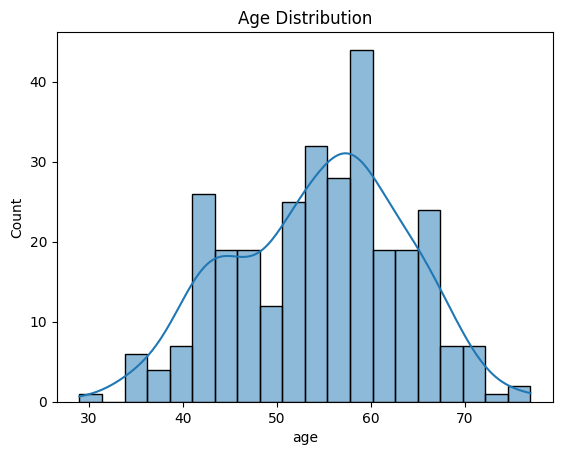

In [ ]:
sns.histplot(data=df, x='age', bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

# Plot Age vs Target

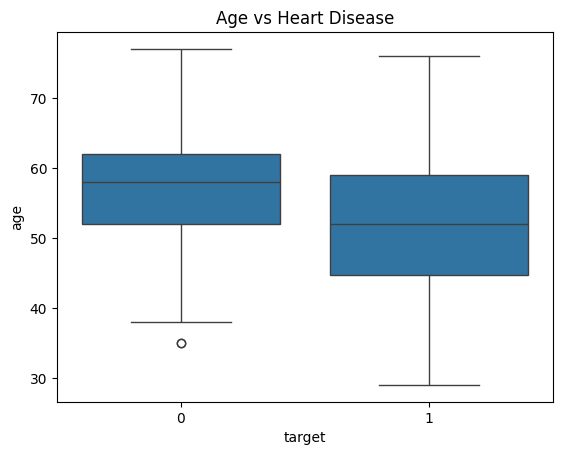

In [ ]:
sns.boxplot(data=df, x='target', y='age')
plt.title('Age vs Heart Disease')
plt.show()

# Plot Chest Pain vs Target

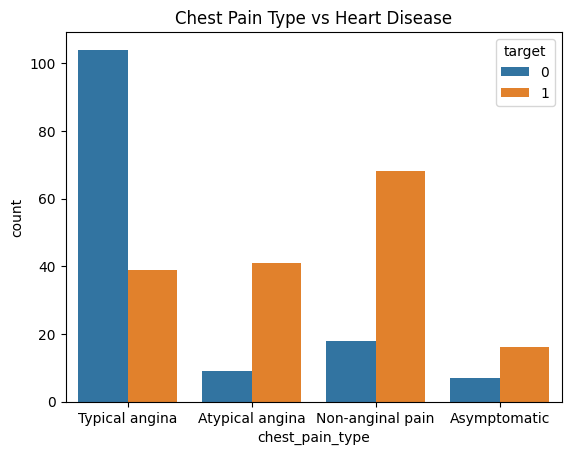

In [ ]:
sns.countplot(data=df, x='chest_pain_type', hue='target')
plt.title('Chest Pain Type vs Heart Disease')
plt.show()

# Plot Correlation Heatmap


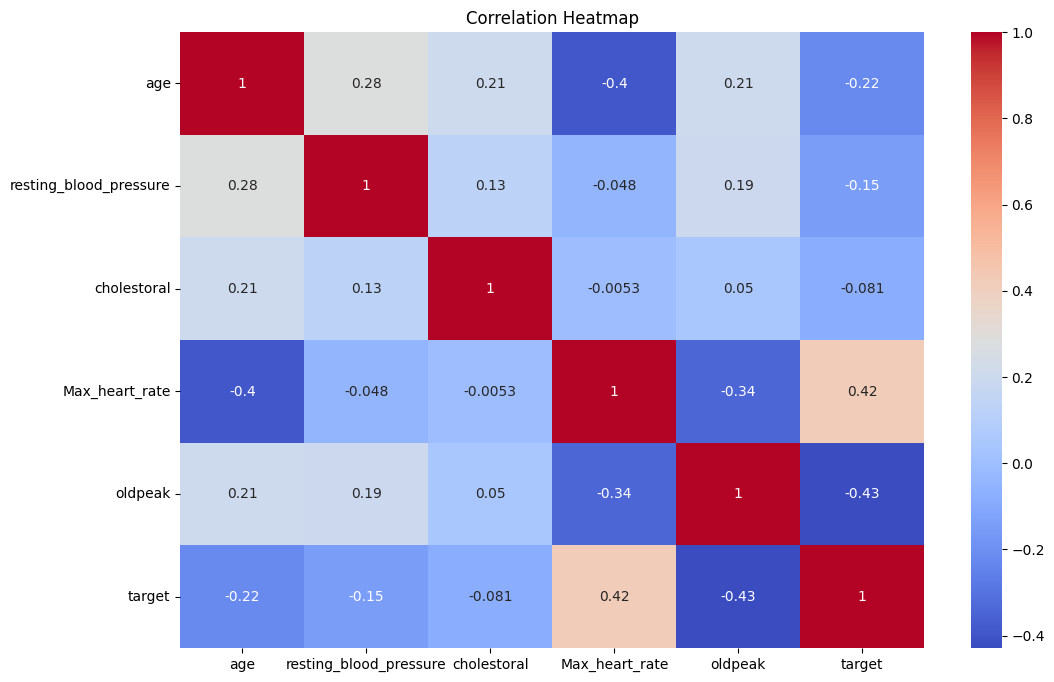

In [ ]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Categorical Encoding

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia'],
    drop_first=True,
    dtype=int
)
df_encoded.head()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target,sex_Male,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,...,exercise_induced_angina_Yes,slope_Flat,slope_Upsloping,vessels_colored_by_flourosopy_One,vessels_colored_by_flourosopy_Three,vessels_colored_by_flourosopy_Two,vessels_colored_by_flourosopy_Zero,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect
0,52,125,212,168,1.0,0,1,0,0,1,...,0,0,0,0,0,1,0,0,0,1
1,53,140,203,155,3.1,0,1,0,0,1,...,1,0,1,0,0,0,1,0,0,1
2,70,145,174,125,2.6,0,1,0,0,1,...,1,0,1,0,0,0,1,0,0,1
3,61,148,203,161,0.0,0,1,0,0,1,...,0,0,0,1,0,0,0,0,0,1
4,62,138,294,106,1.9,0,0,0,0,1,...,0,1,0,0,1,0,0,0,0,0


# Train Test Split

In [ ]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training & Predictions

In [ ]:
logistic_model = LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train)
y_pred_logistic = logistic_model.predict(X_test_scaled)

decision_tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
y_pred_tree = decision_tree.predict(X_test)

svm_model = SVC().fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

knn_model = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

nb_model = GaussianNB().fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)

kmeans_model = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_train_scaled)
kmeans_labels = kmeans_model.predict(X_test_scaled)

# Model Comparison Table

In [ ]:
logistic_acc, logistic_rec = accuracy_score(y_test, y_pred_logistic), recall_score(y_test, y_pred_logistic)
tree_acc, tree_rec = accuracy_score(y_test, y_pred_tree), recall_score(y_test, y_pred_tree)
svm_acc, svm_rec = accuracy_score(y_test, y_pred_svm), recall_score(y_test, y_pred_svm)
knn_acc, knn_rec = accuracy_score(y_test, y_pred_knn), recall_score(y_test, y_pred_knn)
nb_acc, nb_rec = accuracy_score(y_test, y_pred_nb), recall_score(y_test, y_pred_nb)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'SVM', 'KNN', 'Naive Bayes'],
    'Accuracy': [logistic_acc, tree_acc, svm_acc, knn_acc, nb_acc],
    'Recall': [logistic_rec, tree_rec, svm_rec, knn_rec, nb_rec]
})

results

,Model,Accuracy,Recall
0,Logistic Regression,0.836066,0.848485
1,Decision Tree,0.770492,0.757576
2,SVM,0.770492,0.787879
3,KNN,0.819672,0.848485
4,Naive Bayes,0.836066,0.848485


# Classification Report

In [ ]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        28
           1       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



# Plot Confusion Matrix

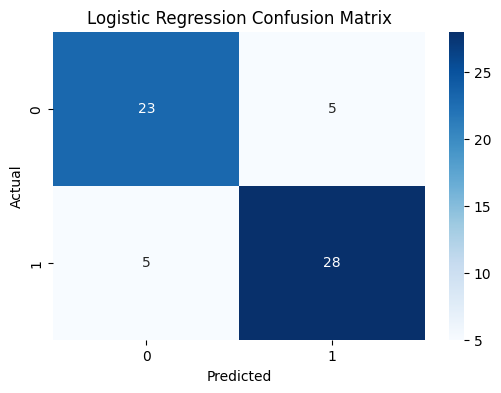

In [ ]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()